In [30]:
# standardard pre-processing of all sequenced cells with wnn integration
library(Seurat)
library(Signac)
library(dplyr)
library(ggplot2)

In [31]:
library(ensembldb)
library(AnnotationHub)
ah <- AnnotationHub(localHub=TRUE)
query(ah, "EnsDb")

Using 'localHub=TRUE'
  If offline, please also see BiocManager vignette section on offline use



AnnotationHub with 1 record
# snapshotDate(): 2022-04-21
# names(): AH73861
# $dataprovider: Ensembl
# $species: Danio rerio
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 97 EnsDb for Danio rerio
# $description: Gene and protein annotations for Danio rerio based on Ensemb...
# $taxonomyid: 7955
# $genome: GRCz11
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("97", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH73861"]]' 

In [32]:
query(ah, "EnsDb")
qr <- query(ah, c("EnsDb", "rerio", "97"))
EnsDb.Drerio.v97 <- qr[[1]]

AnnotationHub with 1 record
# snapshotDate(): 2022-04-21
# names(): AH73861
# $dataprovider: Ensembl
# $species: Danio rerio
# $rdataclass: EnsDb
# $rdatadateadded: 2019-05-02
# $title: Ensembl 97 EnsDb for Danio rerio
# $description: Gene and protein annotations for Danio rerio based on Ensemb...
# $taxonomyid: 7955
# $genome: GRCz11
# $sourcetype: ensembl
# $sourceurl: http://www.ensembl.org
# $sourcesize: NA
# $tags: c("97", "AHEnsDbs", "Annotation", "EnsDb", "Ensembl", "Gene",
#   "Protein", "Transcript") 
# retrieve record with 'object[["AH73861"]]' 

loading from cache



In [33]:
library(hdf5r)
inputdata <- Read10X_h5("./vsx1/outs/filtered_feature_bc_matrix.h5")
rna_counts <- inputdata$`Gene Expression`
atac_counts <- inputdata$'Peaks'


Attaching package: 'hdf5r'


The following object is masked from 'package:GenomicRanges':

    values


The following object is masked from 'package:S4Vectors':

    values


Genome matrix has multiple modalities, returning a list of matrices for this genome



In [34]:
vsx1 <- CreateSeuratObject(counts = rna_counts)
vsx1[["percent.mt"]] <- PercentageFeatureSet(vsx1, pattern = "^mt-")

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"


In [35]:
grange.counts <- StringToGRanges(rownames(atac_counts), sep = c(":", "-"))
grange.use <- seqnames(grange.counts) %in% standardChromosomes(grange.counts)
atac_counts <- atac_counts[as.vector(grange.use), ]
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Drerio.v97)
seqlevelsStyle(annotations) <- 'UCSC'
genome(annotations) <- "GRCz11"
frag.file <- "/home/wangmei/NGS/10x_ARC/spinal_vsx1/vsx1/outs/atac_fragments.tsv.gz"
chrom_assay <- CreateChromatinAssay(
   counts = atac_counts,
   sep = c(":", "-"),
   genome = 'GRCz11',
   fragments = frag.file,
   min.cells = 10,
   annotation = annotations
 )
vsx1[["ATAC"]] <- chrom_assay

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


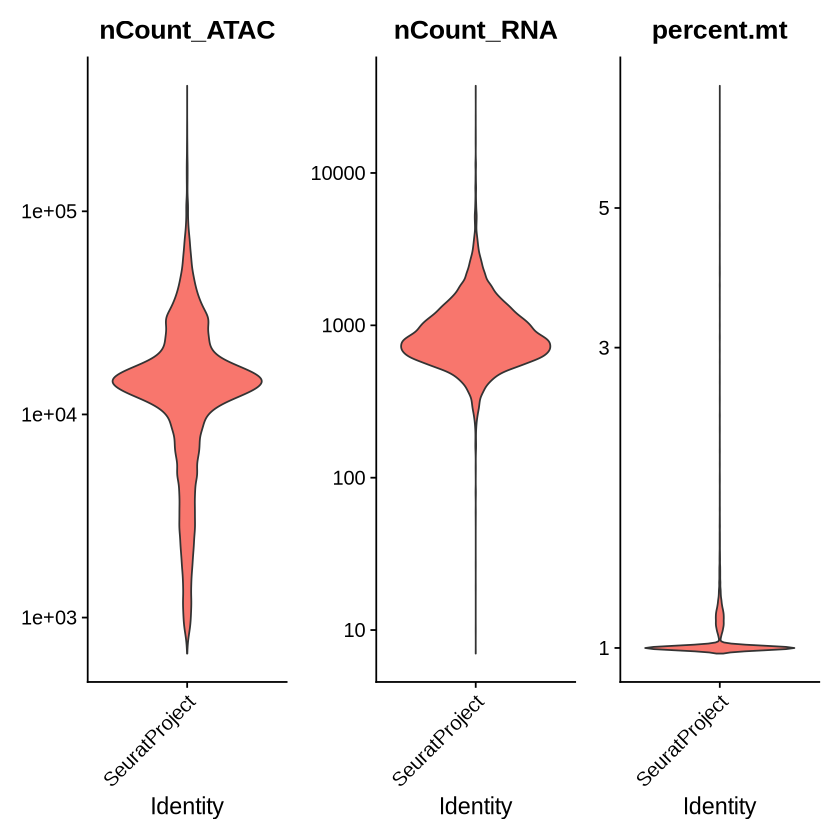

In [36]:
VlnPlot(vsx1, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


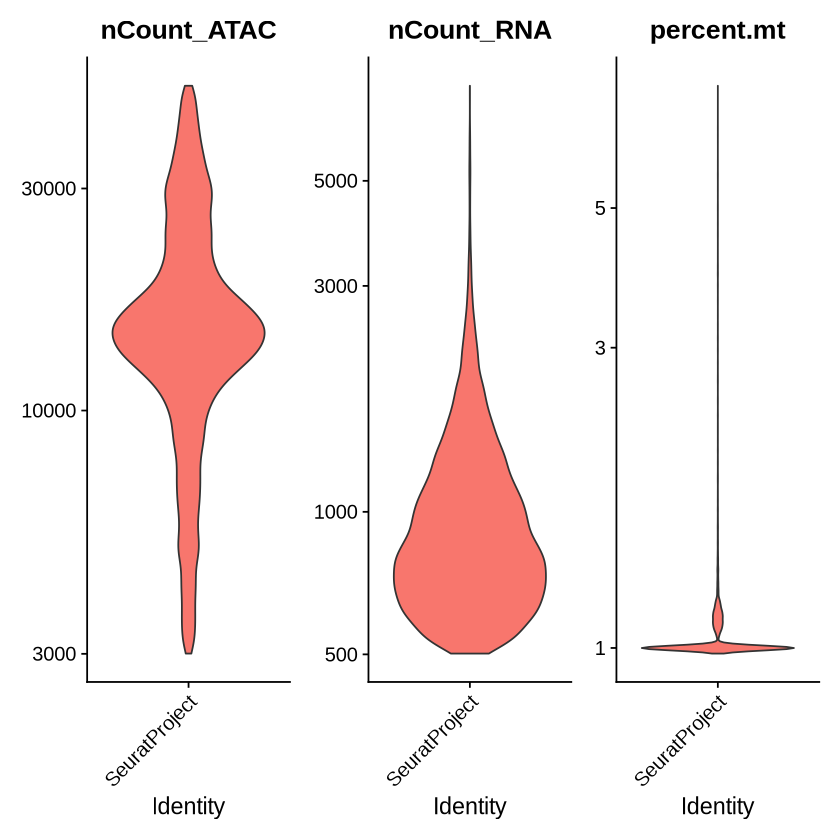

In [37]:
vsx1 <- subset(
  x = vsx1,
  subset = nCount_ATAC < 5e4 &
    nCount_ATAC > 3e3 &
    nCount_RNA < 8000 &
    nCount_RNA > 500
)
VlnPlot(vsx1, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

An object of class Seurat 
336652 features across 11636 samples within 2 assays 
Active assay: RNA (32520 features, 0 variable features)
 1 layer present: counts
 1 other assay present: ATAC

Warning message:
"Default search for "data" layer in "RNA" assay yielded no results; utilizing "counts" layer instead."


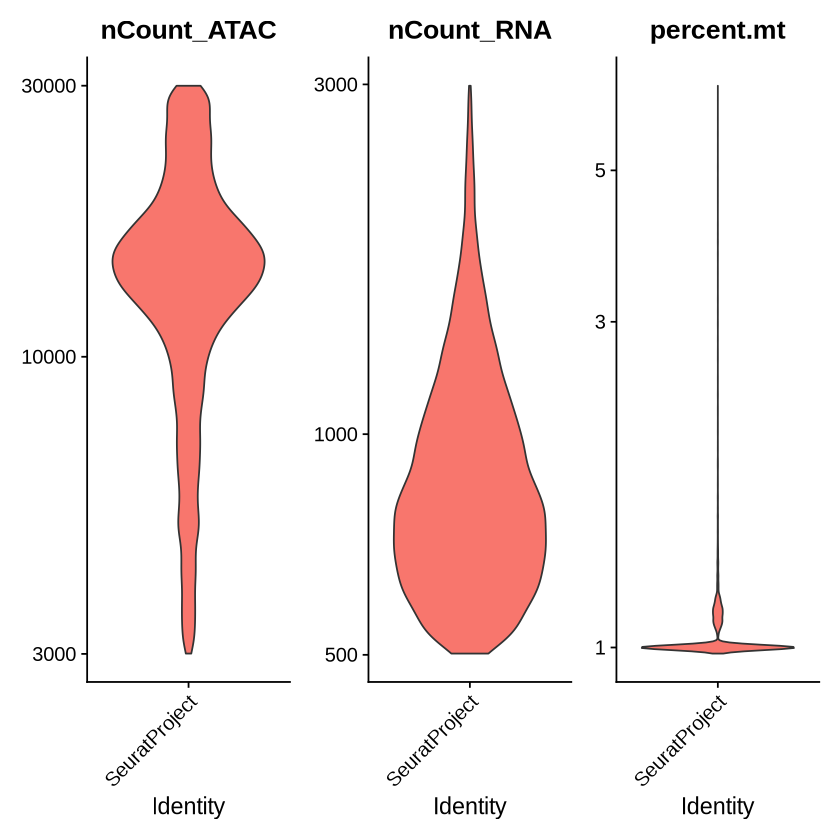

In [38]:
vsx1 <- subset(
  x = vsx1,
  subset = nCount_ATAC < 3e4 &
    nCount_ATAC > 3e3 &
    nCount_RNA < 3000 &
    nCount_RNA > 500
)
vsx1
VlnPlot(vsx1, features = c("nCount_ATAC", "nCount_RNA","percent.mt"), ncol = 3,
  log = TRUE, pt.size = 0) + NoLegend()

In [39]:
DefaultAssay(vsx1) <- "RNA"
vsx1 <- SCTransform(vsx1, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims = 1:50, reduction.name = 'umap.rna', reduction.key = 'rnaUMAP_')
DefaultAssay(vsx1) <- "ATAC"
vsx1 <- RunTFIDF(vsx1)
vsx1 <- FindTopFeatures(vsx1, min.cutoff = 'q0')
vsx1 <- RunSVD(vsx1)
vsx1 <- RunUMAP(vsx1, reduction = 'lsi', dims = 2:50, reduction.name = "umap.atac", reduction.key = "atacUMAP_")
vsx1 <- FindMultiModalNeighbors(vsx1, reduction.list = list("pca", "lsi"), dims.list = list(1:50, 2:50))
vsx1 <- RunUMAP(vsx1, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
vsx1 <- FindClusters(vsx1, graph.name = "wsnn", algorithm = 3, verbose = FALSE)

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = co

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

...

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

15:29:19 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:29:19 Read 11636 rows and found 50 numeric columns

15:29:19 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:29:19 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:29:21 Writing NN index file to temp file /tmp/RtmplFSTnd/file48b09dcc3b93

15:29:21 Searching Annoy index using 1 thread, search_k = 3000

15:29:24 Annoy recall = 100%

15:29:25 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:29:27 Initializing from normalized Laplacian + 

In [40]:
saveRDS(vsx1, file = "vsx1_allcell_wnn.rds")

## replication of Figure S3B

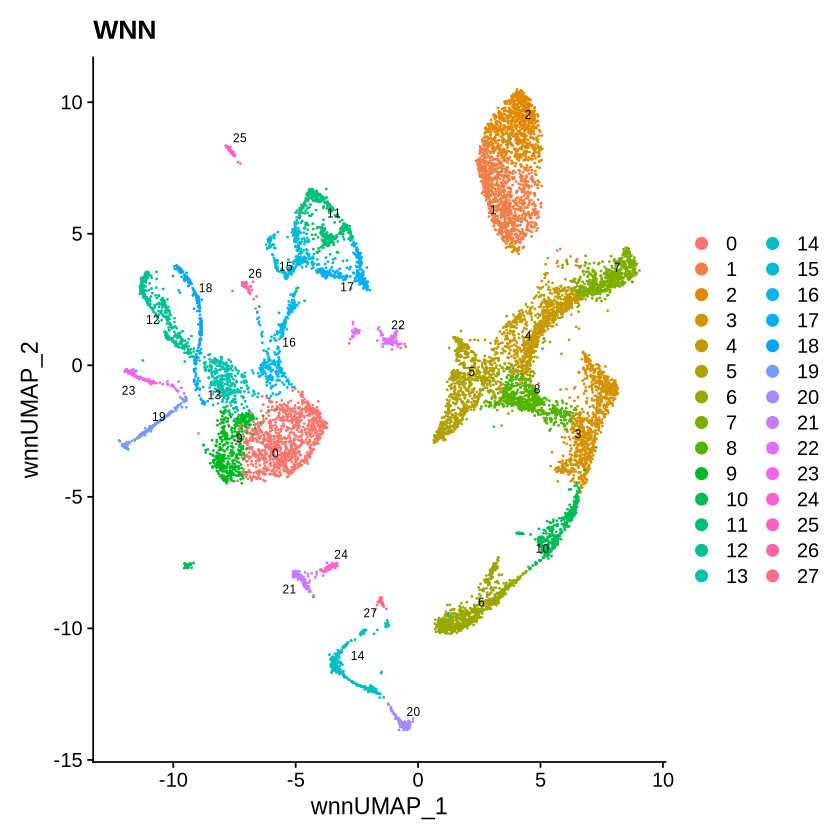

In [41]:
## replication of Figure S3B
DimPlot(vsx1, reduction = "wnn.umap",  label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

In [69]:
pdf("figure3b.pdf")
DimPlot(vsx1, reduction = "wnn.umap",  label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")
dev.off()

pdf 
  2

## check expression of markers of v2a-v2b lineages, replication of Figure S3C

Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"No layers found matching search pattern provided"
Warning message:
"Could not find vsx1 in the default search locations, found in 'SCT' assay instead"
Warning message:
"Could not find tal1 in the default search locations, found in 'SCT' assay instead"
Warning message:
"Could not find vsx2 in the default search locations, found in 'SCT' assay instead"
Warning message:
"Could not find foxn4 in the default search locations, found in 'SCT' assay instead"


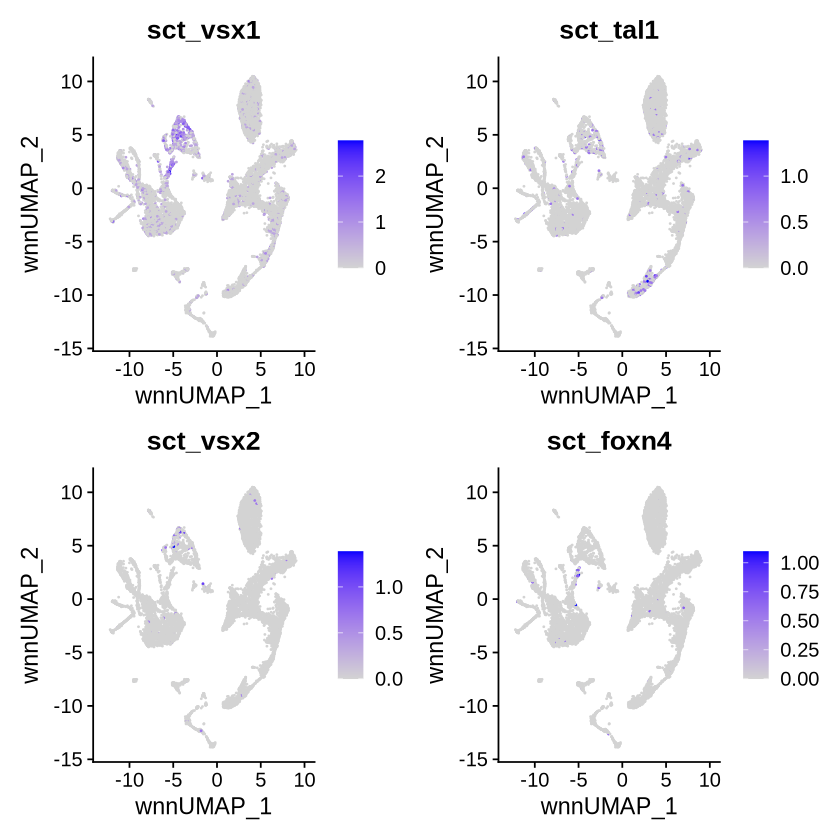

In [42]:
# check expression of v2a-v2b marker genes, replication of Figure S4C
FeaturePlot(vsx1, features = c("vsx1", "tal1", "vsx2", "foxn4"), reduction = 'wnn.umap')

# reanalyze v2a-v2b lineages

In [43]:
#subset and reanalyze v2a-v2b, which highly express vsx1, foxn4, tal1 or vsx2
v2av2b <- subset(vsx1, idents = c("11", "15", "16", "17"))

In [44]:
DefaultAssay(v2av2b) <- "RNA"
v2av2b <- SCTransform(v2av2b, verbose = FALSE) %>% RunPCA() %>% RunUMAP(dims = 1:30, reduction.name = 'umap.rna', reduction.key = 'rnaUMAP_')
DefaultAssay(v2av2b) <- "ATAC"
v2av2b <- RunTFIDF(v2av2b)
v2av2b <- FindTopFeatures(v2av2b, min.cutoff = 'q0')
v2av2b <- RunSVD(v2av2b)

`vst.flavor` is set to 'v2' but could not find glmGamPoi installed.
Please install the glmGamPoi package for much faster estimation.
--------------------------------------------
install.packages('BiocManager')
BiocManager::install('glmGamPoi')
--------------------------------------------
Falling back to native (slower) implementation.


Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = co

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in glm.nb(formula = as.formula(new_formula), data = data):
"alternation limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limi

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
"iteration limit reached"
Warning message in theta.ml(Y, m

15:38:47 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:38:47 Read 1249 rows and found 30 numeric columns

15:38:47 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:38:47 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:38:47 Writing NN index file to temp file /tmp/RtmplFSTnd/file48b09c692888

15:38:47 Searching Annoy index using 1 thread, search_k = 3000

15:38:48 Annoy recall = 100%

15:38:49 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:38:52 Initializing from normalized Laplacian + n

In [45]:
v2av2b <- RunUMAP(v2av2b, reduction = 'lsi', dims = 2:30, n.neighbors = 40L, min.dist = 0.4, reduction.name = "umap.atac", reduction.key = "atacUMAP_")
v2av2b <- FindMultiModalNeighbors(v2av2b, reduction.list = list("pca", "lsi"), dims.list = list(1:30, 2:30))
v2av2b <- RunUMAP(v2av2b, n.neighbors = 40L, min.dist = 0.4, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")

15:39:34 UMAP embedding parameters a = 0.7669 b = 1.223

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:39:34 Read 1249 rows and found 29 numeric columns

15:39:34 Using Annoy for neighbor search, n_neighbors = 40

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

15:39:34 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:39:34 Writing NN index file to temp file /tmp/RtmplFSTnd/file48b0920cedc66

15:39:34 Searching Annoy index using 1 thread, search_k = 4000

15:39:34 Annoy recall = 100%

15:39:36 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 40

15:39:38 Initializing from normalized Laplacian + 

In [46]:
v2av2b <- FindClusters(v2av2b, resolution = 0.6, graph.name = "wsnn", algorithm = 3, verbose = FALSE)

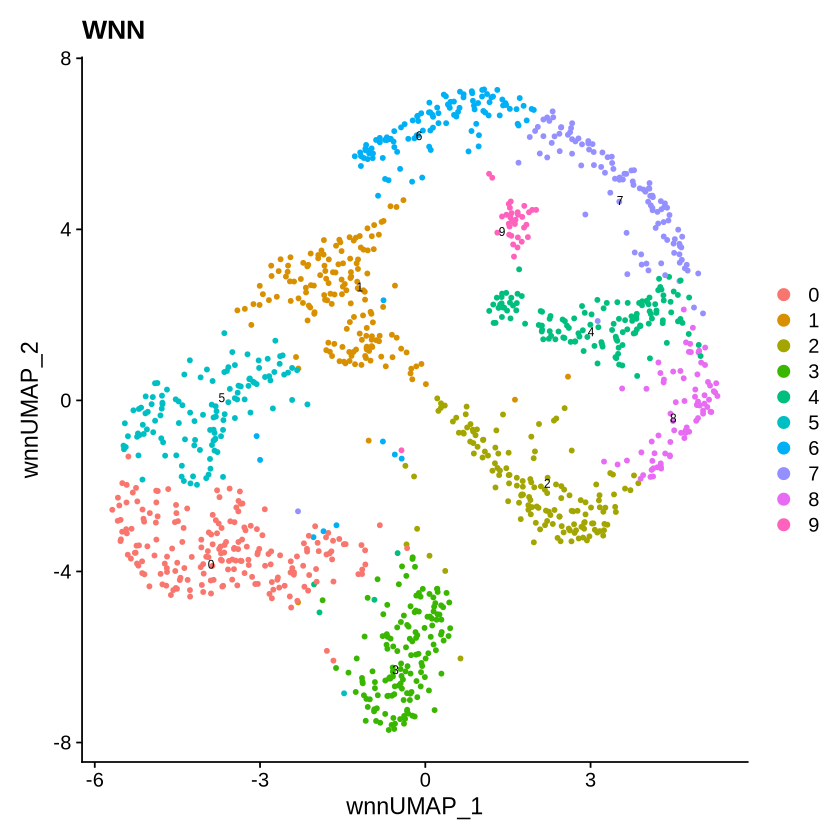

In [47]:
# visualization
DimPlot(v2av2b, reduction = "wnn.umap",  label = TRUE, label.size = 2.5, repel = TRUE) + ggtitle("WNN")

## replication of Figure S3E

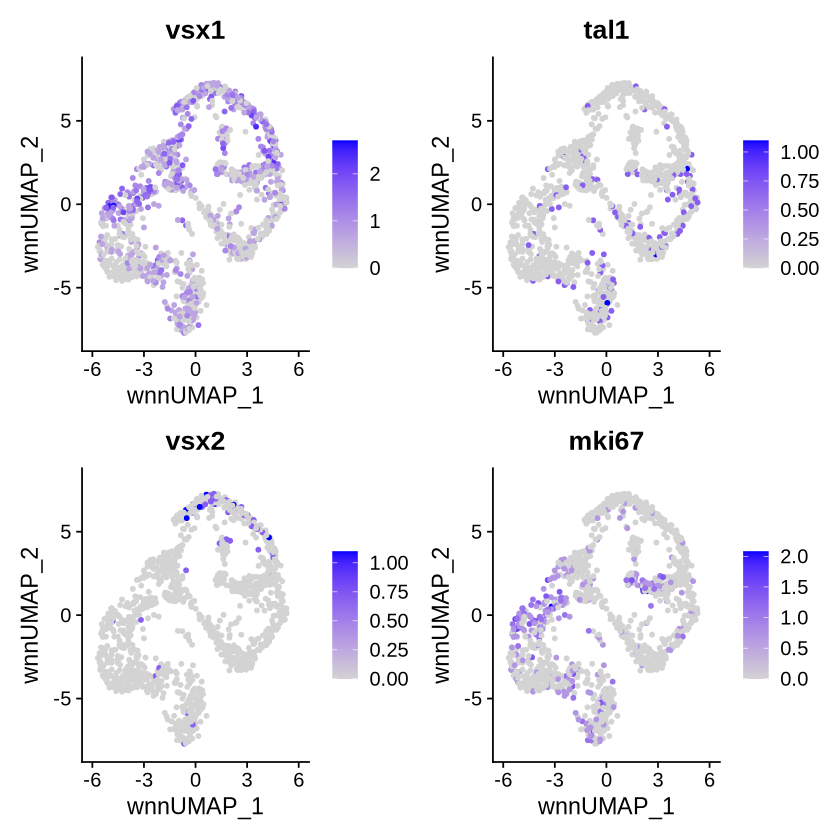

In [48]:
## check expression of marker genes, replication of Figure S3E
DefaultAssay(v2av2b) <- "SCT"
FeaturePlot(v2av2b, features = c("vsx1", "tal1", "vsx2",  "mki67"),  reduction = 'wnn.umap')

## cell type annotation

### replication of Figure S3D

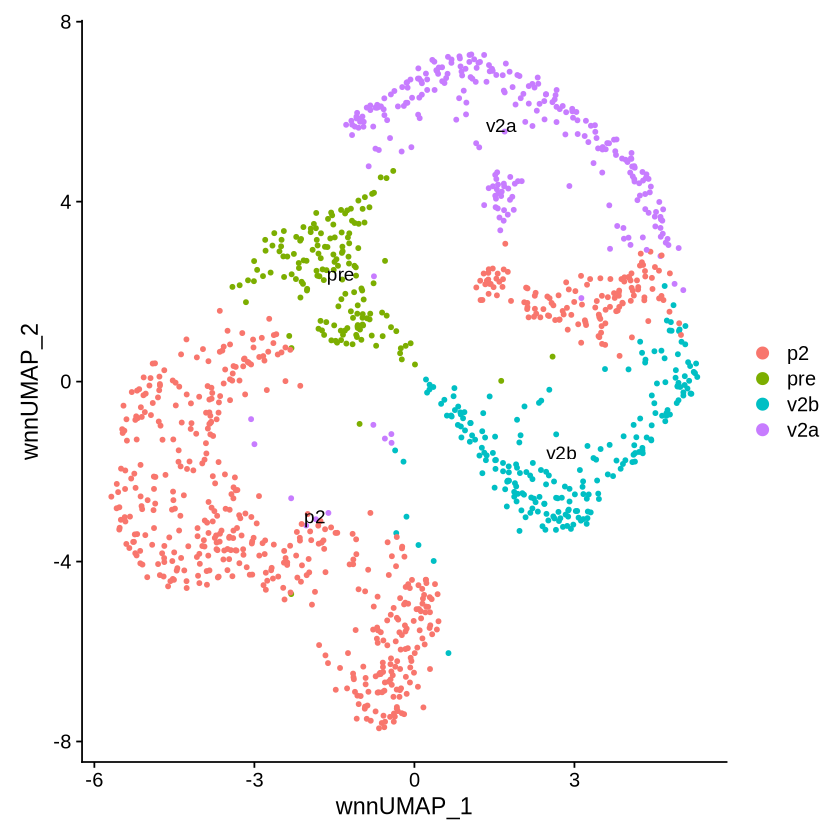

In [49]:
#rename
new.cluster.ids <- c("p2", "pre", "v2b", "p2", "p2", "p2", "v2a", "v2a", "v2b", "v2a")
names(new.cluster.ids) <- levels(v2av2b)
v2av2b <- RenameIdents(v2av2b, new.cluster.ids)
# replication of Figure S3D
DimPlot(v2av2b, reduction = "wnn.umap", label=T)

In [50]:
saveRDS(v2av2b, file = "v2av2b_wnn_annotate.rds")

# analyze 5.8 kb upstream of tal1

In [51]:
library(ensembldb)
seqlevelsStyle(v2av2b$ATAC@annotation) <- "Ensembl"
DefaultAssay(v2av2b) <- "ATAC"

## check DNA accessiblity in tal1 promoter

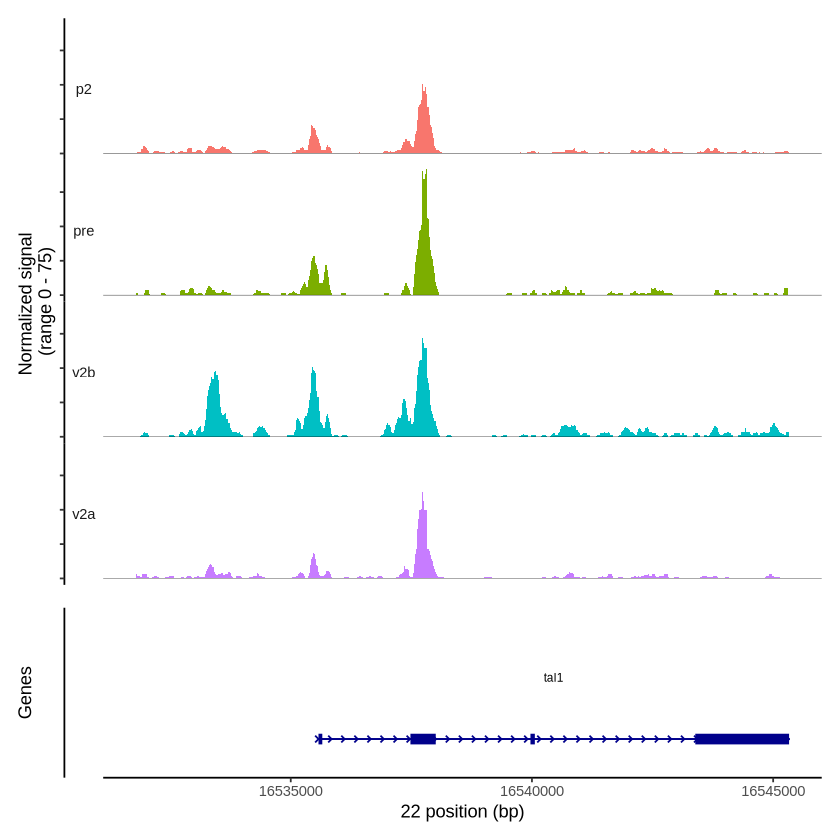

In [52]:
## replication of Figure 2G
CoveragePlot(v2av2b, region = 'tal1', extend.upstream = 3786, extend.downstream = 0, assay = 'ATAC', peaks = FALSE)

# find candidate genes which may repress tal1 activation in precursor cells

## import putative TFs which may bind to tal1 promoter, predicted by animalTFDB4 according to DNA motif analysis

In [53]:
# analyze tal1 upstream repressors
## import candidate genes predicted by animalTFDB4
motifs <- read.csv("TFBSResult_tal1.tsv",sep = "\t", header = T)

## import scRNAseq result

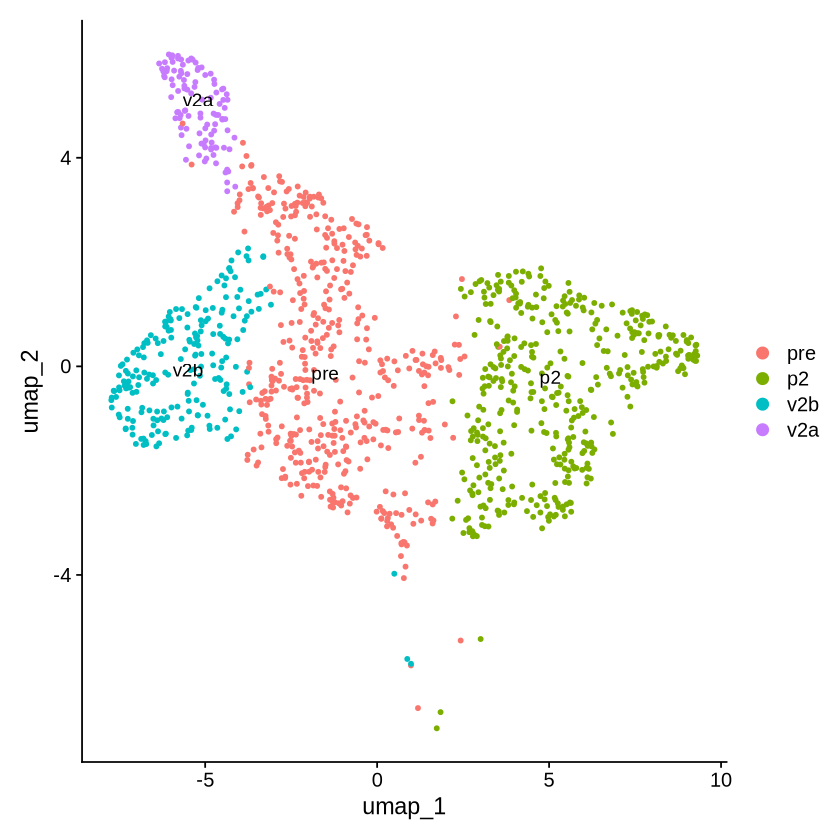

In [54]:
data <- readRDS(file = "/home/wangmei/NGS/scRNA/10x/spinal_vsx1_batch2/v2av2b_rna.rds")
v2av2b_rnaseq <- subset(data, idents = c( "v2a", "v2b", "pre", "p2"))
DimPlot(v2av2b_rnaseq, reduction = "umap", label = TRUE)

## match the imported motif name with gene name in scRNAseq result

In [55]:
## match the imported motif name with gene name in scRNAseq result

## extract and unique motif name, change the name to lower case
list.motif <- unique(tolower(motifs$TF))

## rename the motif pattern "nkx6-2" to "nkx6.2"
list.motif.process <- gsub('-', '.', list.motif)

## extract gene name from scRNAseq result
list.rna <- rownames(v2av2b_rnaseq)


## create a function to find fuzzy matches
find_fuzzy_matches <- function(list.rna, list.motif.process) {
  ## change the gene name to lower case
  list.rna.lower <- tolower(list.rna)

  ## store all matched genes
  matched_genes <- c()
  
  ## for each motif gene, perform fuzzy matching
  for (motif_gene in list.motif.process) {
    matches <- grep(paste0("^", motif_gene, "[a-d]?$"), list.rna.lower, value = FALSE)
    if (length(matches) > 0) {
      matched_genes <- c(matched_genes, list.rna[matches])
    }
  }
  
  ## return unique matched genes
  return(unique(matched_genes))
}

## find fuzzy matches using the function
matched_genes <- find_fuzzy_matches(list.rna, list.motif.process)
length(matched_genes)

[1] 739

## find ummatched processed motifs

In [56]:
## find unmatched motifs using the function
find_unmatched_motifs <- function(list.rna, list.motif.process) {
 list.rna.lower <- tolower(list.rna)
  unmatched_motifs <- c()
  
  ## for each motif gene, check if there is a match
  for (motif_gene in list.motif.process) {
    pattern <- paste0("^", tolower(motif_gene), "[a-d]?$")
    matches <- grep(pattern, list.rna.lower)
    
    ## if no match is found, add the gene to the unmatched list
    if (length(matches) == 0) {
      unmatched_motifs <- c(unmatched_motifs, motif_gene)
    }
  }
  
  return(unmatched_motifs)
}

## find unmatched motifs using the function
unmatched_motifs <- find_unmatched_motifs(list.rna, list.motif.process)
length(unmatched_motifs)
sort(unmatched_motifs)

[1] 346

[1] "alx3"    "anhx"    "argfx"   "arntl"   "ascl2"   "atf6b"   "blimp.1"
  [8] "cdx2"    "cebpe"   "creb3"   "creb3l4" "dmrta1"  "dmrtc2"  "duxbl1" 
 [15] "e2f2"    "e2f6"    "elf4"    "elf5"    "esx1"    "etv3"    "etv6"   
 [22] "foxc2"   "foxr1"   "foxr2"   "gcm1"    "gm5294"  "hand1"   "hes1"   
 [29] "hes2"    "hes5"    "hes7"    "hesx1"   "hkr1"    "hlx"     "hoxa3"  
 [36] "hoxd8"   "hsfy1"   "hsfy2"   "ikzf3"   "isx"     "klf10"   "mesp1"  
 [43] "mzf1"    "nfib"    "nhlh1"   "nkx2.6"  "nkx2.8"  "nobox"   "nr1i3"  
 [50] "ovol2"   "peg3"    "pknox1"  "pou3f4"  "pou5f1"  "pou5f1b" "prdm6"  
 [57] "prrx2"   "rarb"    "rax"     "rax2"    "rbak"    "rhox6"   "rhoxf1" 
 [64] "sohlh2"  "sox15"   "sp110"   "spib"    "spz1"    "sry"     "t"      
 [71] "tcfl5"   "tead2"   "tead4"   "tgif2"   "tgif2lx" "tgif2ly" "ventx"  
 [78] "yy2"     "zbed1"   "zbtb12"  "zbtb5"   "zbtb6"   "zfp105"  "zfp112" 
 [85] "zfp14"   "zfp182"  "zfp184"  "zfp260"  "zfp263"  "zfp28"   "zfp281" 
 [92] "zfp287"  "zfp3"    "zfp30"   "zfp316"  "zfp319"  "zfp322a" "zfp329" 
 [99] "zfp354b" "zfp367"  "zfp37"   "zfp382"  "zfp39"   "zfp41"   "zfp410" 
[106] "zfp414"  "zfp42"   "zfp422"  "zfp46"   "zfp513"  "zfp516"  "zfp526" 
[113] "zfp532"  "zfp536"  "zfp574"  "zfp579"  "zfp583"  "zfp629"  "zfp641" 
[120] "zfp652"  "zfp654"  "zfp664"  "zfp668"  "zfp672"  "zfp689"  "zfp69"  
[127] "zfp69b"  "zfp74"   "zfp740"  "zfp768"  "zfp770"  "zfp771"  "zfp775" 
[134] "zfp784"  "zfp786"  "zfp787"  "zfp800"  "zfp82"   "zfp90"   "zfp92"  
[141] "zik1"    "zkscan1" "zkscan2" "zkscan3" "zkscan5" "zkscan6" "zkscan7"
[148] "znf10"   "znf100"  "znf114"  "znf133"  "znf134"  "znf135"  "znf136" 
[155] "znf140"  "znf141"  "znf154"  "znf16"   "znf17"   "znf174"  "znf175" 
[162] "znf177"  "znf182"  "znf189"  "znf197"  "znf200"  "znf211"  "znf212" 
[169] "znf213"  "znf214"  "znf22"   "znf222"  "znf224"  "znf225"  "znf23"  
[176] "znf232"  "znf235"  "znf24"   "znf248"  "znf25"   "znf250"  "znf254" 
[183] "znf257"  "znf26"   "znf260"  "znf263"  "znf264"  "znf267"  "znf273" 
[190] "znf274"  "znf280a" "znf282"  "znf283"  "znf284"  "znf285"  "znf287" 
[197] "znf3"    "znf30"   "znf300"  "znf302"  "znf304"  "znf311"  "znf317" 
[204] "znf32"   "znf320"  "znf324"  "znf331"  "znf333"  "znf334"  "znf337" 
[211] "znf33a"  "znf33b"  "znf34"   "znf343"  "znf35"   "znf350"  "znf354a"
[218] "znf354b" "znf37a"  "znf382"  "znf383"  "znf384"  "znf394"  "znf41"  
[225] "znf415"  "znf416"  "znf417"  "znf418"  "znf419"  "znf429"  "znf431" 
[232] "znf432"  "znf433"  "znf436"  "znf441"  "znf442"  "znf444"  "znf445" 
[239] "znf449"  "znf45"   "znf454"  "znf460"  "znf467"  "znf468"  "znf479" 
[246] "znf480"  "znf483"  "znf484"  "znf487"  "znf490"  "znf492"  "znf501" 
[253] "znf502"  "znf506"  "znf519"  "znf524"  "znf529"  "znf530"  "znf534" 
[260] "znf540"  "znf543"  "znf547"  "znf548"  "znf549"  "znf554"  "znf555" 
[267] "znf558"  "znf561"  "znf563"  "znf565"  "znf567"  "znf570"  "znf571" 
[274] "znf573"  "znf580"  "znf582"  "znf585a" "znf586"  "znf594"  "znf595" 
[281] "znf597"  "znf605"  "znf610"  "znf611"  "znf613"  "znf614"  "znf619" 
[288] "znf626"  "znf660"  "znf662"  "znf667"  "znf680"  "znf681"  "znf682" 
[295] "znf684"  "znf695"  "znf701"  "znf707"  "znf708"  "znf71"   "znf713" 
[302] "znf716"  "znf736"  "znf737"  "znf749"  "znf75a"  "znf75d"  "znf764" 
[309] "znf766"  "znf77"   "znf774"  "znf776"  "znf777"  "znf778"  "znf780a"
[316] "znf782"  "znf784"  "znf785"  "znf787"  "znf789"  "znf79"   "znf792" 
[323] "znf799"  "znf8"    "znf805"  "znf81"   "znf816"  "znf860"  "znf879" 
[330] "znf880"  "znf891"  "znf90"   "znf93"   "znf98"   "zscan1"  "zscan10"
[337] "zscan16" "zscan2"  "zscan22" "zscan23" "zscan31" "zscan4"  "zscan4c"
[344] "zscan5"  "zscan5c" "zscan9"

## mannually add genes to macthed gene list if needed

In [57]:
## manually add genes if to matched gene list if needed
suppli.genes <- c("her2", "her1", "her5", "her4.1", "hes2.1", "hes2.2", "her4.2", "her6", "her9", "her12", "her15.1" )
matched_genes <- unique(c(matched_genes, suppli.genes))
length(matched_genes)

[1] 750

## calculate average expression of matched genes in each cell type

In [58]:
## calculate average expression of matched genes in each cell type
avg_exp <- AverageExpression(v2av2b_rnaseq, features = matched_genes)$RNA 
avg_exp_df <- as.data.frame(avg_exp)
avg_exp_df$Gene <- rownames(avg_exp_df)
head(avg_exp_df)  

,pre,p2,v2b,v2a,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
e2f7,0.059906187,0.36208690,0.02823589,0.00000000,e2f7
pou3f2a,0.046614859,0.08031858,0.03531259,0.05886236,pou3f2a
foxm1,0.020936260,0.45254702,0.00000000,0.01769314,foxm1
tfec,0.003107309,0.00000000,0.00000000,0.00000000,tfec
foxp2,0.680576918,0.37682638,0.71915126,0.51967816,foxp2
elk3,0.019571789,0.01500275,0.03452456,0.02774233,elk3


# select genes which positively express in pre

In [59]:
## select genes which positively express in pre
pre.positive <- avg_exp_df[avg_exp_df$pre > 0.15, ]
dim(pre.positive)
head(pre.positive)

[1] 188   5

,pre,p2,v2b,v2a,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
foxp2,0.6805769,0.3768264,0.7191513,0.51967816,foxp2
nfyba,3.1272978,2.5286109,3.0372930,2.79330358,nfyba
nrf1,0.5337509,0.4917505,0.4044177,0.30022477,nrf1
gata3,0.9246195,0.1465764,8.1781805,0.04743105,gata3
nr2c1,0.3988785,0.2978335,0.3851893,0.35374993,nr2c1
arnt2,1.3687060,1.2897490,1.3792969,1.29758275,arnt2


# find out genes which express significantly higher in v2a than in v2b

In [60]:
## find genes which express higher in v2a than in v2b
gene.pre <- pre.positive$Gene
gene.pre <- as.character(gene.pre)
v2a.markers <- FindMarkers(v2av2b_rnaseq, ident.1 = "v2a", ident.2 = "v2b", features = gene.pre, only.pos = TRUE)


In [61]:
## select the significant genes, p_val < 0.05, avg_log2FC > 1
v2a.markers <- v2a.markers[v2a.markers$p_val < 0.05, ]
v2a.markers.sig <- v2a.markers[v2a.markers$avg_log2FC > 1, ]
dim(v2a.markers.sig)

[1] 15  5

# check average expression of v2a significant TFs in p2

In [62]:
## check average expression of v2a significant TFs in p2
avg_exp_df[rownames(v2a.markers.sig), ]

,pre,p2,v2b,v2a,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
vsx2,1.2341788,0.02520809,0.005675024,4.0549325,vsx2
lhx4,1.0226829,0.04197694,0.039016208,1.5027582,lhx4
vsx1,8.5695863,11.20851128,1.187059537,8.3487308,vsx1
nkx6.1,0.6970386,0.43032452,0.061267526,1.2163309,nkx6.1
LHX3,0.1686863,0.15183081,0.021009491,0.4293526,LHX3
hoxc6b,2.0359554,1.55347540,3.681638620,10.3735907,hoxc6b
zeb1b,1.0140896,0.63989241,0.524546970,1.4838917,zeb1b
mafaa,0.1674391,0.01073526,0.010843212,0.3723025,mafaa
klf7a,0.9792306,0.59164697,0.266448634,0.6645772,klf7a


## draw the heatmap of v2a-specific genes, replication of Figure 2H

Centering and scaling data matrix

Warning message:
"Different features in new layer data than already exists for scale.data"
Warning message in DoHeatmap(v2av2b_rnaseq, features = c(rownames(v2a.markers.sig), :
"The following features were omitted as they were not found in the scale.data slot for the RNA assay: 5"


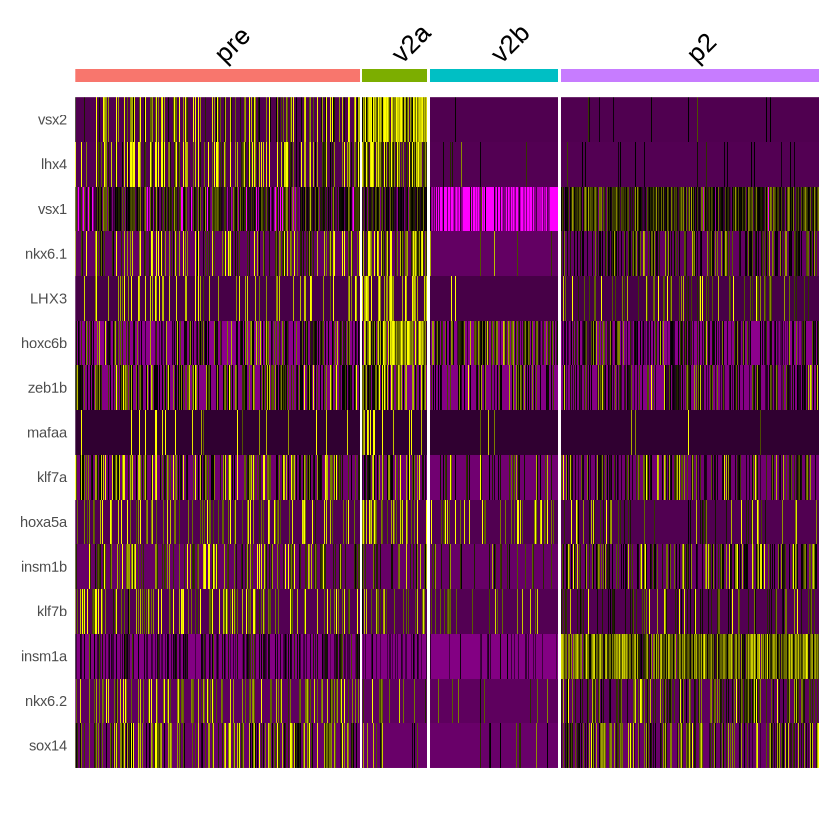

In [63]:
## draw the heatmap of v2a-specific genes, replication of Figure 2H
v2av2b_rnaseq <- ScaleData(v2av2b_rnaseq, features = gene.pre)
v2av2b_rnaseq@active.ident <- factor(
  v2av2b_rnaseq@active.ident,
  levels = c("pre", "v2a", "v2b", "p2")  # set the representation order 
)

DoHeatmap(v2av2b_rnaseq, features = c(rownames(v2a.markers.sig), lines.width = 5)) + NoLegend()

# environment

In [64]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/wangmei/anaconda3/envs/seurat5/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] hdf5r_1.3.11            AnnotationHub_3.10.0    BiocFileCache_2.10.1   
 [4] dbplyr_2.5.0            ensembldb_2.26.0        AnnotationFilter_1.26.0
 [7] GenomicFeatures_1.54.1  AnnotationDbi_1.64.1   

In [65]:
sessioninfo::session_info(to_file = "env_v2av2b_multiomic_tal1repressor.md")

In [66]:
save.image(file = "v2av2b_multiomic_tal1repressor.RData")